# Digital Twin Model for Ship Operations

This notebook develops a data-driven digital twin workflow for ship voyage analysis.  
The model estimates:

1. Economic sailing speed  
2. Fuel consumption per voyage  
3. Fuel cost  
4. CO2 emissions per voyage  

The workflow combines ship technical parameters, voyage information, environmental conditions, and machine learning models.

1. Libraries and Configuration

In [1]:
import os
import math
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

Project Paths

In [2]:
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/Digital Twin - Ships/data.xlsx"

OUTPUT_DIR = "/content/drive/MyDrive/Digital Twin - Ships/outputs"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

SPEED_MODEL_PATH = os.path.join(MODEL_DIR, "economic_speed_model.pkl")
FUEL_MODEL_PATH = os.path.join(MODEL_DIR, "fuel_consumption_model.pkl")
CO2_MODEL_PATH = os.path.join(MODEL_DIR, "co2_emission_model.pkl")

FUEL_PRICE_USD_PER_MT = 1100.0
CO2_EMISSION_FACTOR = 3.114

RANDOM_STATE = 42
TEST_SIZE = 0.20

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Dataset Loading

In [3]:
df = pd.read_excel(DATA_PATH)
df.columns = df.columns.str.strip()

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset shape: (803, 95)


,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Weather_Condition,Başlangıç Şehri,Varış Şehri,Geçilen Deniz/Okyanus,Sea_Water_Density_kg_m3,...,Effective_Power_kW,Shaft_Power_kW,Predicted_Fuel_kg_h,Predicted_CO2_kg_h,Air_Density_kg_m3,Fuel_Cost_per_Voyage_USD,Total_CO2_per_Voyage_kg,CO2_kg_per_nm,Fuel_kg_per_nm,Economic_Speed_knots
0,2023-06-04,Bulk Carrier,Short-haul,Diesel,Critical,Rough,İzmir,Atina,Ege Denizi,1028,...,30042.631536,42918.045051,7345.088490,22872.605557,0.620657,388.872171,1100.861764,0.775696,0.249100,20.918037
1,2023-06-04,Bulk Carrier,Short-haul,Diesel,NaN,Calm,Hong Kong,Haiphong,Güney Çin Denizi,1023,...,7199.537878,10285.054111,1820.140210,5667.916614,0.609765,454.597168,1286.923257,1.589671,0.510492,13.156641
2,2023-06-04,Bulk Carrier,Long-haul,Diesel,Good,Calm,Perth,Colombo,Hint Okyanusu,1025,...,35839.755242,51199.650346,8929.154108,27805.385893,0.614678,288.547488,816.851706,1.611877,0.517623,25.904509
3,2023-06-11,Bulk Carrier,Short-haul,Diesel,NaN,Moderate,Dubrovnik,Bari,Adriyatik Denizi,1028,...,18021.307896,25744.725566,4413.750117,13744.417864,0.614544,242.431053,686.300271,0.994210,0.319271,18.681516
4,2023-06-11,Bulk Carrier,Coastal,Diesel,Critical,Moderate,Valensiya,Cezayir,Akdeniz,1028,...,8848.183870,12640.262671,2249.138220,7003.816416,0.620349,487.339730,1379.614471,2.666413,0.856266,14.532434


3. Helper Functions

In [4]:
def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ])

    return preprocessor, numeric_cols, categorical_cols


def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape
    }


def run_cross_validation(pipeline, X, y):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    cv_rmse = np.sqrt(
        -cross_val_score(
            pipeline,
            X,
            y,
            cv=cv,
            scoring="neg_mean_squared_error",
            n_jobs=-1
        )
    )

    cv_mae = -cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    cv_r2 = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    return {
        "CV_RMSE_mean": cv_rmse.mean(),
        "CV_RMSE_std": cv_rmse.std(),
        "CV_MAE_mean": cv_mae.mean(),
        "CV_MAE_std": cv_mae.std(),
        "CV_R2_mean": cv_r2.mean(),
        "CV_R2_std": cv_r2.std()
    }


def get_feature_table(pipeline):
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    model = pipeline.named_steps["model"]

    if hasattr(model, "coef_"):
        values = model.coef_
        column_name = "Coefficient"
        table = pd.DataFrame({
            "Feature": feature_names,
            column_name: values,
            "Abs_Value": np.abs(values)
        }).sort_values(by="Abs_Value", ascending=False)

    elif hasattr(model, "feature_importances_"):
        values = model.feature_importances_
        column_name = "Importance"
        table = pd.DataFrame({
            "Feature": feature_names,
            column_name: values
        }).sort_values(by=column_name, ascending=False)

    else:
        table = pd.DataFrame({
            "Feature": feature_names
        })

    return table


def align_features_for_model(model, data):
    expected_cols = model.feature_names_in_.tolist()
    aligned = data.copy()

    for col in expected_cols:
        if col not in aligned.columns:
            aligned[col] = np.nan

    return aligned[expected_cols]


def save_actual_vs_predicted_plot(y_true, y_pred, title, xlabel, ylabel, path):
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.65)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()


def save_residual_plot(y_true, y_pred, title, path):
    residuals = y_true - y_pred

    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals, alpha=0.65)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted value")
    plt.ylabel("Residual")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()


def save_error_distribution_plot(y_true, y_pred, title, path):
    residuals = y_true - y_pred

    plt.figure(figsize=(7, 5))
    plt.hist(residuals, bins=30)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()


def save_top_features_plot(feature_df, title, path, top_n=20):
    if "Importance" in feature_df.columns:
        value_col = "Importance"
    elif "Abs_Value" in feature_df.columns:
        value_col = "Abs_Value"
    else:
        return

    top_features = feature_df.head(top_n).sort_values(by=value_col, ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(top_features["Feature"], top_features[value_col])
    plt.xlabel(value_col)
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

Shared Drop Columns

In [5]:
COMMON_DROP_COLS = [
    "Date",
    "Speed_Over_Ground_knots",
    "Voyage_Duration_hours (Underway/Sea time)",
    "STW",
    "Operational_Cost_USD",
    "Revenue_per_Voyage_USD",
    "Efficiency_nm_per_kWh",
    "Speed_m_s",
    "Hs_total_m",
    "Tp_rep_s",
    "Reynolds_Number",
    "Cf_ITTC",
    "Froude_Number",
    "Voyage_Efficiency",
    "Predicted_Weather_Speed_m_s",
    "Predicted_Weather_Speed_knots",
    "Speed_Loss_knots",
    "Speed_Loss_percent",
    "Effective_Power_kW",
    "Shaft_Power_kW",
    "Predicted_Fuel_kg_h",
    "Predicted_CO2_kg_h",
    "Fuel_Cost_per_Voyage_USD",
    "Total_CO2_per_Voyage_kg",
    "CO2_kg_per_nm",
    "Fuel_kg_per_nm"
]

4. ## Model 1: Economic Speed Estimation

The first model estimates the most efficient operating speed of the vessel.  
The target variable is `Economic_Speed_knots`.

A Ridge Regression model is used because it provides a stable and interpretable baseline for a continuous speed prediction problem.

Train Economic Speed Model

In [6]:
TARGET_SPEED = "Economic_Speed_knots"

if TARGET_SPEED not in df.columns:
    raise ValueError(f"Target column not found: {TARGET_SPEED}")

speed_df = df.dropna(subset=[TARGET_SPEED]).copy()

speed_drop_cols = COMMON_DROP_COLS + [
    TARGET_SPEED,
    "Fuel_Consumption_per_Voyage"
]

existing_drop_cols = [col for col in speed_drop_cols if col in speed_df.columns]

X_speed = speed_df.drop(columns=existing_drop_cols, errors="ignore").copy()
y_speed = speed_df[TARGET_SPEED].copy()

print("Economic speed model dataset shape:", X_speed.shape)

X_train_speed, X_test_speed, y_train_speed, y_test_speed = train_test_split(
    X_speed,
    y_speed,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

speed_preprocessor, speed_numeric_cols, speed_categorical_cols = build_preprocessor(X_speed)

speed_model = Ridge(alpha=1.0)

speed_pipeline = Pipeline(steps=[
    ("preprocessor", speed_preprocessor),
    ("model", speed_model)
])

speed_pipeline.fit(X_train_speed, y_train_speed)

y_pred_speed = speed_pipeline.predict(X_test_speed)

speed_metrics = evaluate_regression(y_test_speed, y_pred_speed)
speed_cv_metrics = run_cross_validation(speed_pipeline, X_speed, y_speed)

speed_metrics_df = pd.DataFrame({
    "Metric": list(speed_metrics.keys()) + list(speed_cv_metrics.keys()),
    "Value": list(speed_metrics.values()) + list(speed_cv_metrics.values())
})

print("Economic Speed Model Performance")
display(speed_metrics_df)

speed_feature_df = get_feature_table(speed_pipeline)

print("Top 20 features for the economic speed model:")
display(speed_feature_df.head(20))

Economic speed model dataset shape: (803, 67)
Economic Speed Model Performance


,Metric,Value
0,MAE,0.134813
1,RMSE,0.178358
2,R2,0.998929
3,MAPE_percent,1.206016
4,CV_RMSE_mean,0.173276
5,CV_RMSE_std,0.015921
6,CV_MAE_mean,0.128941
7,CV_MAE_std,0.010333
8,CV_R2_mean,0.998975
9,CV_R2_std,0.000142


Top 20 features for the economic speed model:


,Feature,Coefficient,Abs_Value
51,num__Relative_Wind_m_s,7.111701,7.111701
31,num__wind_speed_m_s,-5.090083,5.090083
54,num__Air_Resistance_N,-0.591693,0.591693
52,num__Projected_Area_m2,0.308839,0.308839
53,num__Cd_air,-0.281544,0.281544
48,num__Calm_Water_Resistance_N,0.281374,0.281374
47,num__Friction_Resistance_N,0.261836,0.261836
37,num__Wetted_Surface_Area_m2,-0.192675,0.192675
49,num__Wave_Added_Resistance_N,0.191933,0.191933
40,num__swell_wave_height_m,-0.183674,0.183674


Save Economic Speed Outputs

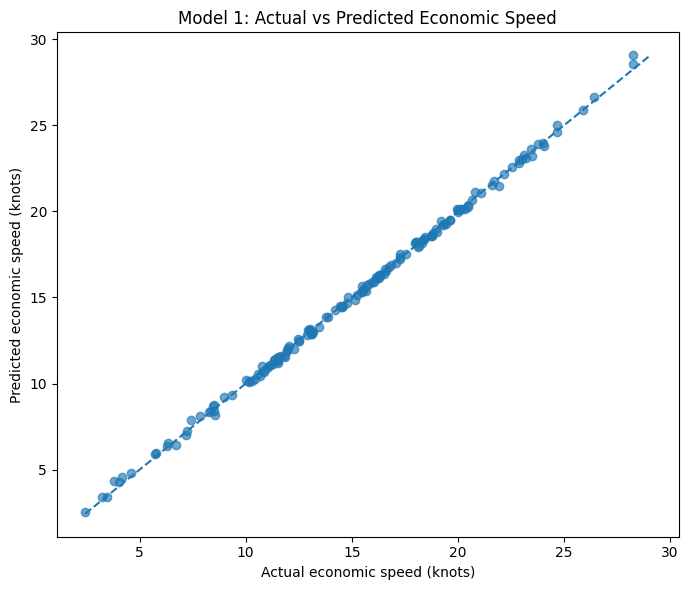

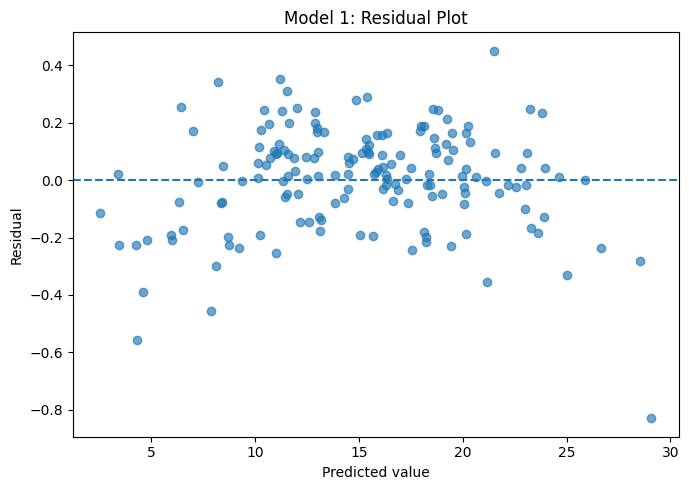

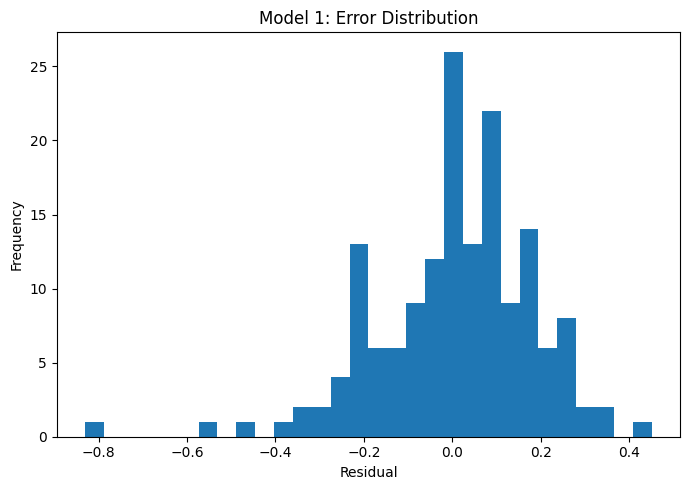

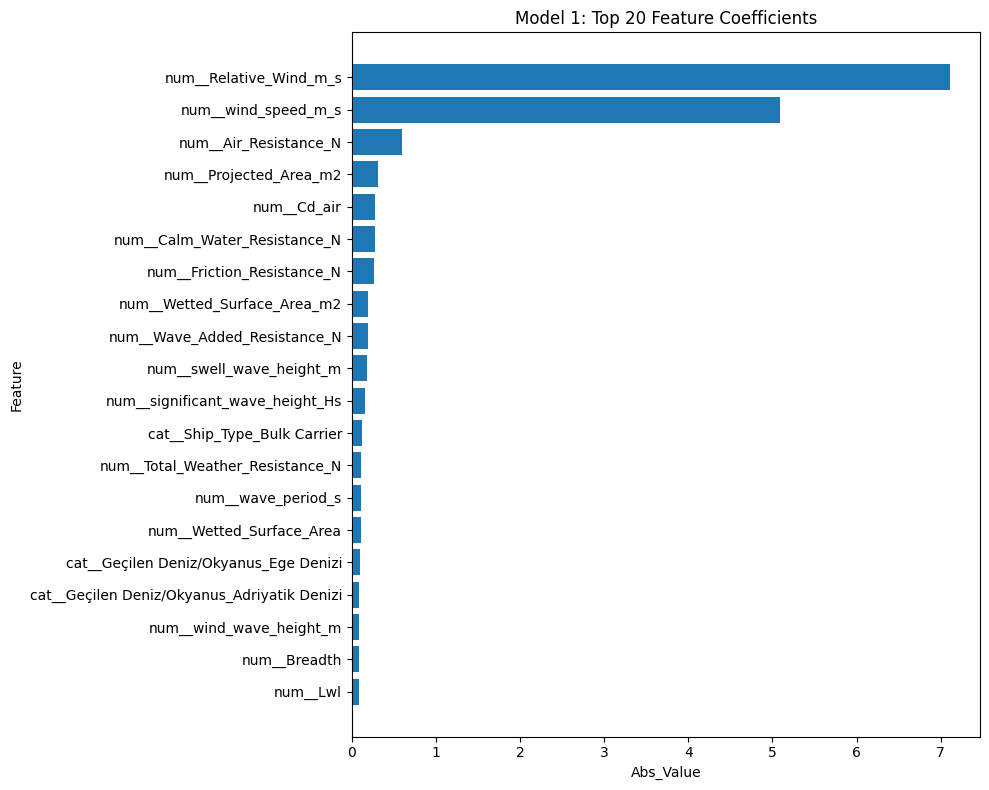

Economic speed model and outputs saved.
/content/drive/MyDrive/Digital Twin - Ships/outputs/models/economic_speed_model.pkl


In [7]:
speed_results_df = speed_df.copy()
speed_results_df["Predicted_Economic_Speed_knots"] = speed_pipeline.predict(X_speed)
speed_results_df["Economic_Speed_Error_knots"] = (
    speed_results_df["Predicted_Economic_Speed_knots"] - speed_results_df[TARGET_SPEED]
)

speed_test_results_df = X_test_speed.copy()
speed_test_results_df["Actual_Economic_Speed_knots"] = y_test_speed.values
speed_test_results_df["Predicted_Economic_Speed_knots"] = y_pred_speed
speed_test_results_df["Residual_knots"] = (
    speed_test_results_df["Actual_Economic_Speed_knots"]
    - speed_test_results_df["Predicted_Economic_Speed_knots"]
)

joblib.dump(speed_pipeline, SPEED_MODEL_PATH)

speed_metrics_path = os.path.join(REPORT_DIR, "model1_speed_metrics.xlsx")
speed_results_path = os.path.join(REPORT_DIR, "model1_speed_full_predictions.xlsx")
speed_test_path = os.path.join(REPORT_DIR, "model1_speed_test_results.xlsx")
speed_features_path = os.path.join(REPORT_DIR, "model1_speed_feature_coefficients.xlsx")

speed_metrics_df.to_excel(speed_metrics_path, index=False)
speed_results_df.to_excel(speed_results_path, index=False)
speed_test_results_df.to_excel(speed_test_path, index=False)
speed_feature_df.to_excel(speed_features_path, index=False)

save_actual_vs_predicted_plot(
    y_test_speed,
    y_pred_speed,
    "Model 1: Actual vs Predicted Economic Speed",
    "Actual economic speed (knots)",
    "Predicted economic speed (knots)",
    os.path.join(PLOT_DIR, "model1_actual_vs_predicted.png")
)

save_residual_plot(
    y_test_speed,
    y_pred_speed,
    "Model 1: Residual Plot",
    os.path.join(PLOT_DIR, "model1_residual_plot.png")
)

save_error_distribution_plot(
    y_test_speed,
    y_pred_speed,
    "Model 1: Error Distribution",
    os.path.join(PLOT_DIR, "model1_error_distribution.png")
)

save_top_features_plot(
    speed_feature_df,
    "Model 1: Top 20 Feature Coefficients",
    os.path.join(PLOT_DIR, "model1_top_features.png")
)

print("Economic speed model and outputs saved.")
print(SPEED_MODEL_PATH)

5. ## Model 2: Fuel Consumption Estimation

The second model estimates the total fuel consumption per voyage.  
The estimated economic speed from Model 1 is added as an input feature.

The target variable is `Fuel_Consumption_per_Voyage`.

Train Fuel Consumption Model

In [8]:
TARGET_FUEL = "Fuel_Consumption_per_Voyage"

if TARGET_FUEL not in df.columns:
    raise ValueError(f"Target column not found: {TARGET_FUEL}")

fuel_df = df.dropna(subset=[TARGET_FUEL]).copy()

speed_input_for_fuel = align_features_for_model(speed_pipeline, fuel_df)
fuel_df["Predicted_Economic_Speed_knots"] = speed_pipeline.predict(speed_input_for_fuel)

fuel_drop_cols = COMMON_DROP_COLS + [
    TARGET_FUEL,
    "Economic_Speed_knots",
    "Predicted_Fuel_kg_h",
    "Fuel_Cost_per_Voyage_USD",
    "Predicted_CO2_kg_h",
    "Total_CO2_per_Voyage_kg",
    "CO2_kg_per_nm",
    "Fuel_kg_per_nm"
]

existing_drop_cols = [col for col in fuel_drop_cols if col in fuel_df.columns]

X_fuel = fuel_df.drop(columns=existing_drop_cols, errors="ignore").copy()
y_fuel = fuel_df[TARGET_FUEL].copy()

print("Fuel model dataset shape:", X_fuel.shape)

X_train_fuel, X_test_fuel, y_train_fuel, y_test_fuel = train_test_split(
    X_fuel,
    y_fuel,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

fuel_preprocessor, fuel_numeric_cols, fuel_categorical_cols = build_preprocessor(X_fuel)

fuel_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

fuel_pipeline = Pipeline(steps=[
    ("preprocessor", fuel_preprocessor),
    ("model", fuel_model)
])

fuel_pipeline.fit(X_train_fuel, y_train_fuel)

y_pred_fuel = fuel_pipeline.predict(X_test_fuel)

fuel_metrics = evaluate_regression(y_test_fuel, y_pred_fuel)
fuel_cv_metrics = run_cross_validation(fuel_pipeline, X_fuel, y_fuel)

fuel_metrics_df = pd.DataFrame({
    "Metric": list(fuel_metrics.keys()) + list(fuel_cv_metrics.keys()),
    "Value": list(fuel_metrics.values()) + list(fuel_cv_metrics.values())
})

print("Fuel Consumption Model Performance")
display(fuel_metrics_df)

fuel_feature_df = get_feature_table(fuel_pipeline)

print("Top 20 features for the fuel consumption model:")
display(fuel_feature_df.head(20))

Fuel model dataset shape: (803, 68)
Fuel Consumption Model Performance


,Metric,Value
0,MAE,4.188986
1,RMSE,5.432053
2,R2,0.998218
3,MAPE_percent,1.579837
4,CV_RMSE_mean,5.285380
5,CV_RMSE_std,0.296143
6,CV_MAE_mean,4.158834
7,CV_MAE_std,0.245558
8,CV_R2_mean,0.998164
9,CV_R2_std,0.000235


Top 20 features for the fuel consumption model:


,Feature,Importance
21,num__Engine_Power_kW,0.993411
25,num__Specific_Fuel_Consumption,0.004776
24,num__Propulsive_Power,0.000147
1,num__Distance_Traveled_nm,0.000071
4,num__Seasonal_Impact_Score,0.000060
23,num__Engine_Load,0.000060
3,num__Cargo_Weight_tons,0.000058
6,num__Average_Load_Percentage,0.000054
33,num__wind_v10,0.000054
20,num__Propeller_Efficiency,0.000050


Save Fuel Model Outputs

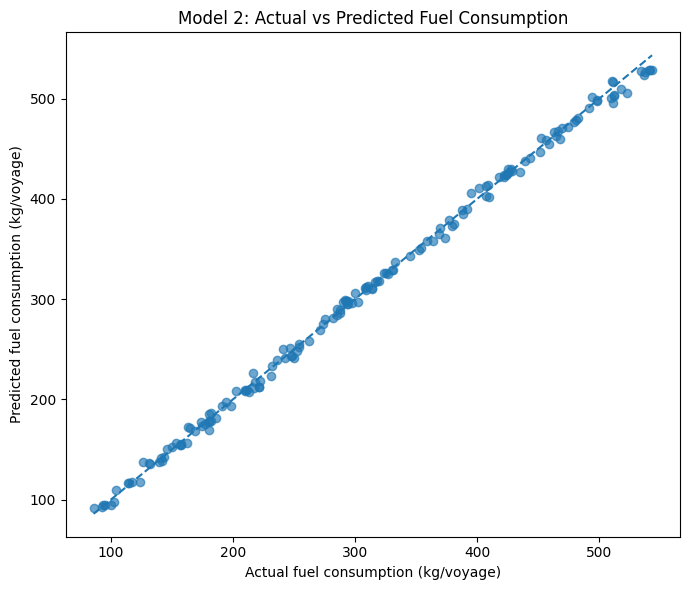

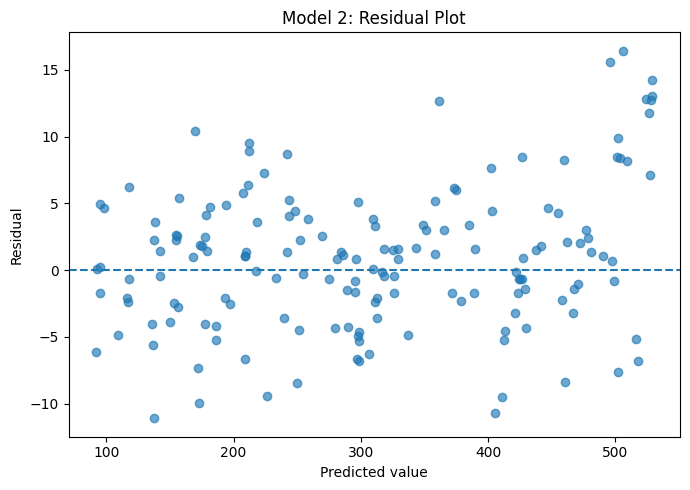

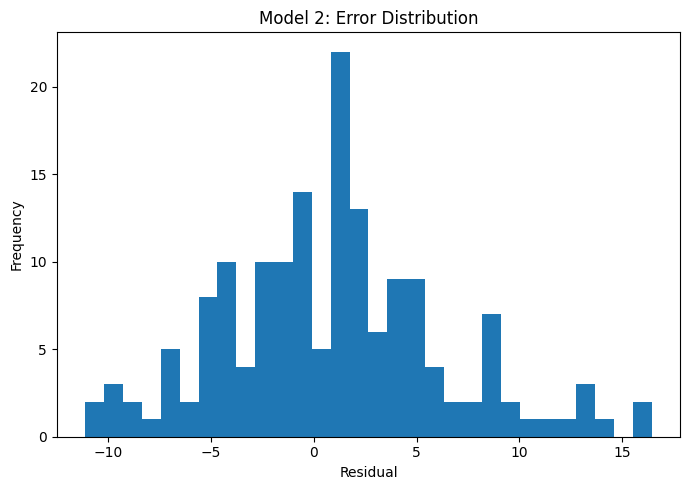

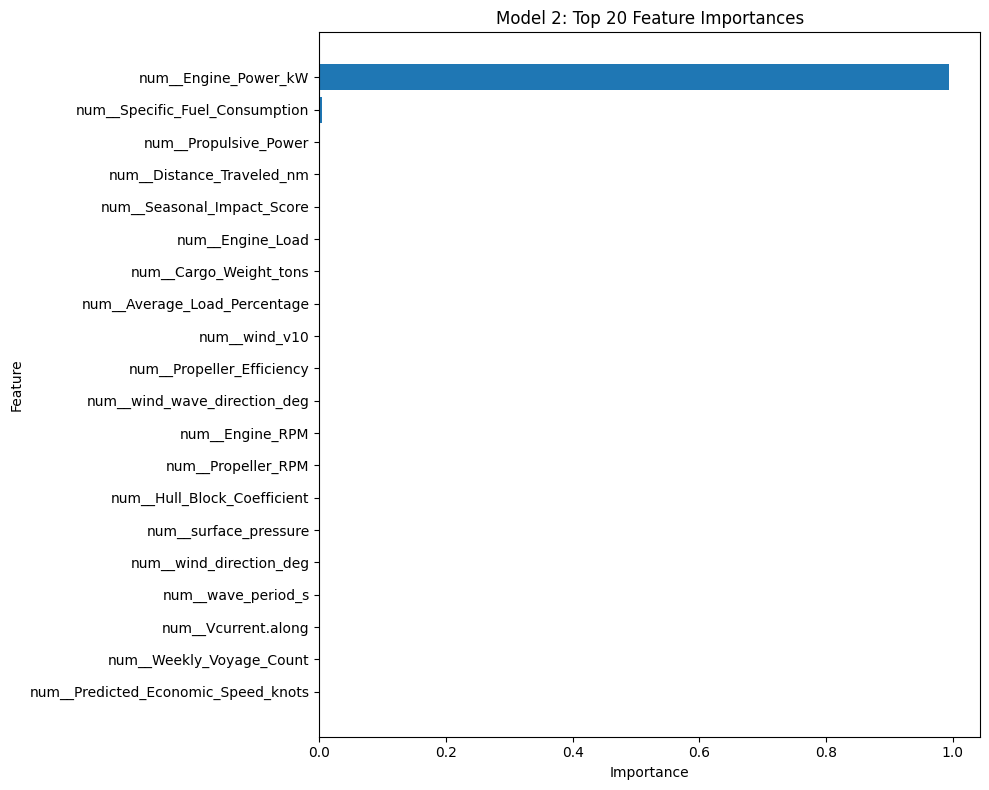

Fuel consumption model and outputs saved.
/content/drive/MyDrive/Digital Twin - Ships/outputs/models/fuel_consumption_model.pkl


In [9]:
fuel_results_df = fuel_df.copy()
fuel_results_df["Predicted_Fuel_Consumption_per_Voyage"] = fuel_pipeline.predict(X_fuel)
fuel_results_df["Fuel_Consumption_Error_kg"] = (
    fuel_results_df["Predicted_Fuel_Consumption_per_Voyage"] - fuel_results_df[TARGET_FUEL]
)

fuel_results_df["Predicted_Fuel_Cost_USD"] = (
    fuel_results_df["Predicted_Fuel_Consumption_per_Voyage"] / 1000.0
) * FUEL_PRICE_USD_PER_MT

if "Fuel_Cost_per_Voyage_USD" in fuel_results_df.columns:
    fuel_results_df["Fuel_Cost_Error_USD"] = (
        fuel_results_df["Predicted_Fuel_Cost_USD"]
        - fuel_results_df["Fuel_Cost_per_Voyage_USD"]
    )

fuel_test_results_df = X_test_fuel.copy()
fuel_test_results_df["Actual_Fuel_Consumption_per_Voyage"] = y_test_fuel.values
fuel_test_results_df["Predicted_Fuel_Consumption_per_Voyage"] = y_pred_fuel
fuel_test_results_df["Residual_kg"] = (
    fuel_test_results_df["Actual_Fuel_Consumption_per_Voyage"]
    - fuel_test_results_df["Predicted_Fuel_Consumption_per_Voyage"]
)
fuel_test_results_df["Predicted_Fuel_Cost_USD"] = (
    fuel_test_results_df["Predicted_Fuel_Consumption_per_Voyage"] / 1000.0
) * FUEL_PRICE_USD_PER_MT

joblib.dump(fuel_pipeline, FUEL_MODEL_PATH)

fuel_metrics_path = os.path.join(REPORT_DIR, "model2_fuel_metrics.xlsx")
fuel_results_path = os.path.join(REPORT_DIR, "model2_fuel_full_predictions.xlsx")
fuel_test_path = os.path.join(REPORT_DIR, "model2_fuel_test_results.xlsx")
fuel_features_path = os.path.join(REPORT_DIR, "model2_fuel_feature_importance.xlsx")

fuel_metrics_df.to_excel(fuel_metrics_path, index=False)
fuel_results_df.to_excel(fuel_results_path, index=False)
fuel_test_results_df.to_excel(fuel_test_path, index=False)
fuel_feature_df.to_excel(fuel_features_path, index=False)

save_actual_vs_predicted_plot(
    y_test_fuel,
    y_pred_fuel,
    "Model 2: Actual vs Predicted Fuel Consumption",
    "Actual fuel consumption (kg/voyage)",
    "Predicted fuel consumption (kg/voyage)",
    os.path.join(PLOT_DIR, "model2_actual_vs_predicted.png")
)

save_residual_plot(
    y_test_fuel,
    y_pred_fuel,
    "Model 2: Residual Plot",
    os.path.join(PLOT_DIR, "model2_residual_plot.png")
)

save_error_distribution_plot(
    y_test_fuel,
    y_pred_fuel,
    "Model 2: Error Distribution",
    os.path.join(PLOT_DIR, "model2_error_distribution.png")
)

save_top_features_plot(
    fuel_feature_df,
    "Model 2: Top 20 Feature Importances",
    os.path.join(PLOT_DIR, "model2_top_features.png")
)

print("Fuel consumption model and outputs saved.")
print(FUEL_MODEL_PATH)

6. ## Model 3: CO2 Emission Estimation

The third model estimates total CO2 emissions per voyage.  
The predicted economic speed and predicted fuel consumption are used as additional input features.

The target variable is `Total_CO2_per_Voyage_kg`.

A formula-based CO2 estimate is also calculated from predicted fuel consumption for comparison.

Train CO2 Emission Model

In [10]:
TARGET_CO2 = "Total_CO2_per_Voyage_kg"

if TARGET_CO2 not in df.columns:
    raise ValueError(f"Target column not found: {TARGET_CO2}")

co2_df = df.dropna(subset=[TARGET_CO2]).copy()

speed_input_for_co2 = align_features_for_model(speed_pipeline, co2_df)
co2_df["Predicted_Economic_Speed_knots"] = speed_pipeline.predict(speed_input_for_co2)

fuel_input_for_co2 = align_features_for_model(fuel_pipeline, co2_df)
co2_df["Predicted_Fuel_Consumption_per_Voyage"] = fuel_pipeline.predict(fuel_input_for_co2)

co2_df["Formula_CO2_from_Predicted_Fuel_kg"] = (
    co2_df["Predicted_Fuel_Consumption_per_Voyage"] * CO2_EMISSION_FACTOR
)

co2_drop_cols = COMMON_DROP_COLS + [
    TARGET_CO2,
    "Economic_Speed_knots",
    "Fuel_Consumption_per_Voyage",
    "Predicted_CO2_kg_h",
    "CO2_kg_per_nm",
    "Fuel_Cost_per_Voyage_USD"
]

existing_drop_cols = [col for col in co2_drop_cols if col in co2_df.columns]

X_co2 = co2_df.drop(columns=existing_drop_cols, errors="ignore").copy()
y_co2 = co2_df[TARGET_CO2].copy()

print("CO2 model dataset shape:", X_co2.shape)

X_train_co2, X_test_co2, y_train_co2, y_test_co2 = train_test_split(
    X_co2,
    y_co2,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

co2_preprocessor, co2_numeric_cols, co2_categorical_cols = build_preprocessor(X_co2)

co2_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

co2_pipeline = Pipeline(steps=[
    ("preprocessor", co2_preprocessor),
    ("model", co2_model)
])

co2_pipeline.fit(X_train_co2, y_train_co2)

y_pred_co2 = co2_pipeline.predict(X_test_co2)

co2_metrics = evaluate_regression(y_test_co2, y_pred_co2)
co2_cv_metrics = run_cross_validation(co2_pipeline, X_co2, y_co2)

co2_metrics_df = pd.DataFrame({
    "Metric": list(co2_metrics.keys()) + list(co2_cv_metrics.keys()),
    "Value": list(co2_metrics.values()) + list(co2_cv_metrics.values())
})

print("CO2 Emission Model Performance")
display(co2_metrics_df)

co2_feature_df = get_feature_table(co2_pipeline)

print("Top 20 features for the CO2 emission model:")
display(co2_feature_df.head(20))

CO2 model dataset shape: (803, 70)
CO2 Emission Model Performance


,Metric,Value
0,MAE,12.327611
1,RMSE,15.806505
2,R2,0.998444
3,MAPE_percent,1.564586
4,CV_RMSE_mean,10.202551
5,CV_RMSE_std,2.812147
6,CV_MAE_mean,7.887627
7,CV_MAE_std,2.216857
8,CV_R2_mean,0.999262
9,CV_R2_std,0.000410


Top 20 features for the CO2 emission model:


,Feature,Importance
59,num__Formula_CO2_from_Predicted_Fuel_kg,0.512622
58,num__Predicted_Fuel_Consumption_per_Voyage,0.485618
21,num__Engine_Power_kW,0.001410
25,num__Specific_Fuel_Consumption,0.000016
4,num__Seasonal_Impact_Score,0.000012
3,num__Cargo_Weight_tons,0.000010
34,num__surface_pressure,0.000010
20,num__Propeller_Efficiency,0.000009
23,num__Engine_Load,0.000009
24,num__Propulsive_Power,0.000009


Save CO2 Model Outputs

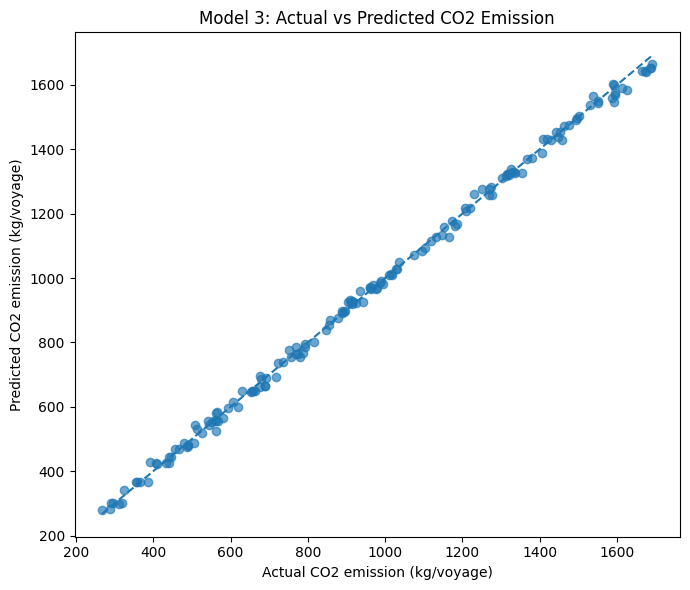

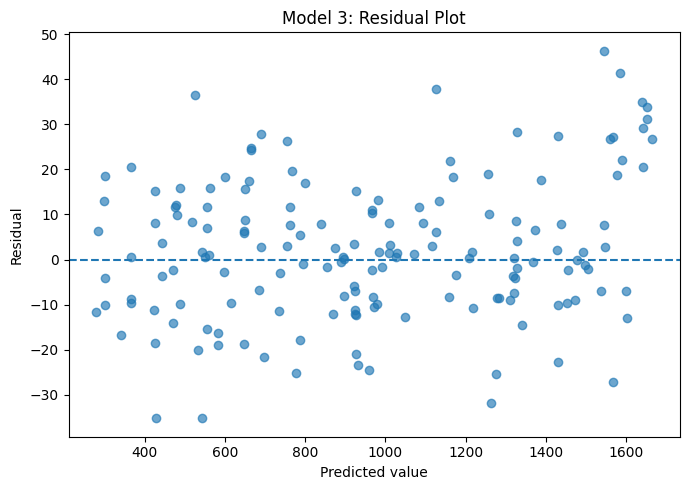

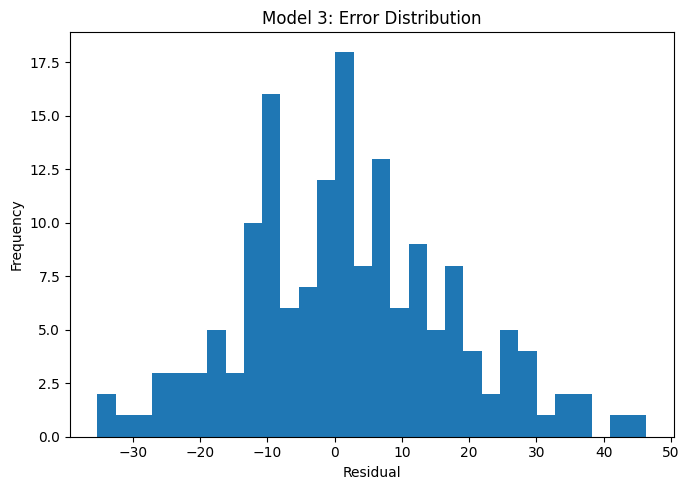

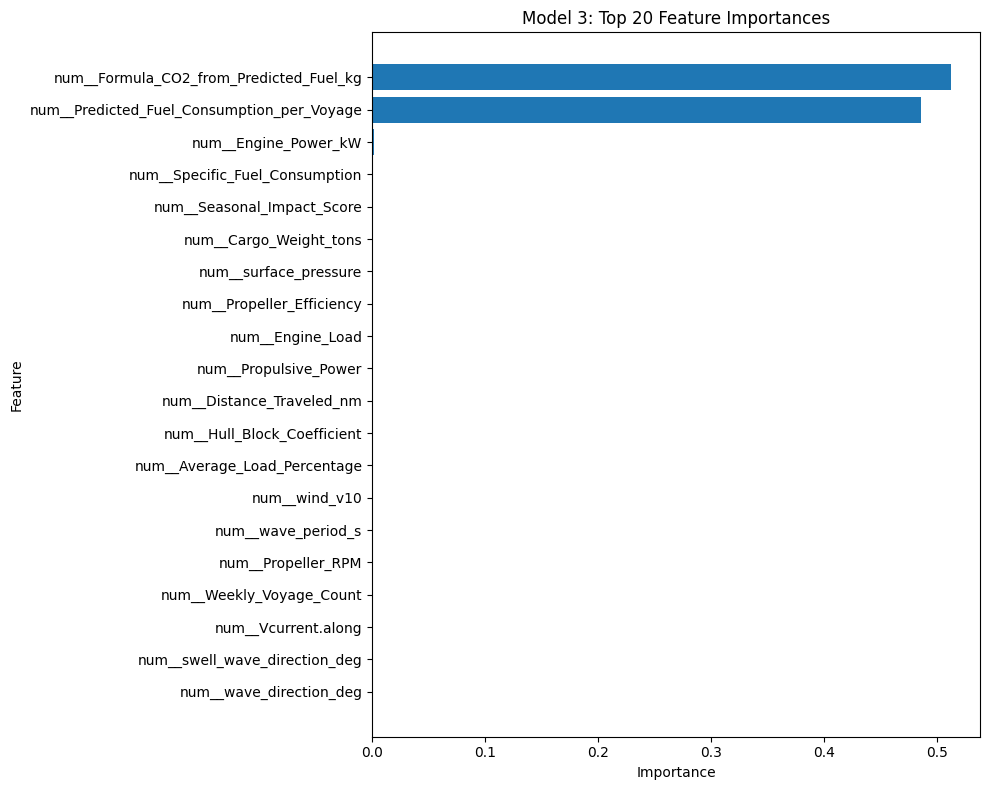

CO2 emission model and outputs saved.
/content/drive/MyDrive/Digital Twin - Ships/outputs/models/co2_emission_model.pkl


In [11]:
co2_results_df = co2_df.copy()
co2_results_df["Predicted_Total_CO2_per_Voyage_kg"] = co2_pipeline.predict(X_co2)
co2_results_df["CO2_Error_kg"] = (
    co2_results_df["Predicted_Total_CO2_per_Voyage_kg"] - co2_results_df[TARGET_CO2]
)

co2_test_results_df = X_test_co2.copy()
co2_test_results_df["Actual_Total_CO2_per_Voyage_kg"] = y_test_co2.values
co2_test_results_df["Predicted_Total_CO2_per_Voyage_kg"] = y_pred_co2
co2_test_results_df["Residual_kg"] = (
    co2_test_results_df["Actual_Total_CO2_per_Voyage_kg"]
    - co2_test_results_df["Predicted_Total_CO2_per_Voyage_kg"]
)

co2_test_results_df["Formula_CO2_from_Predicted_Fuel_kg"] = co2_df.loc[
    X_test_co2.index,
    "Formula_CO2_from_Predicted_Fuel_kg"
].values

joblib.dump(co2_pipeline, CO2_MODEL_PATH)

co2_metrics_path = os.path.join(REPORT_DIR, "model3_co2_metrics.xlsx")
co2_results_path = os.path.join(REPORT_DIR, "model3_co2_full_predictions.xlsx")
co2_test_path = os.path.join(REPORT_DIR, "model3_co2_test_results.xlsx")
co2_features_path = os.path.join(REPORT_DIR, "model3_co2_feature_importance.xlsx")

co2_metrics_df.to_excel(co2_metrics_path, index=False)
co2_results_df.to_excel(co2_results_path, index=False)
co2_test_results_df.to_excel(co2_test_path, index=False)
co2_feature_df.to_excel(co2_features_path, index=False)

save_actual_vs_predicted_plot(
    y_test_co2,
    y_pred_co2,
    "Model 3: Actual vs Predicted CO2 Emission",
    "Actual CO2 emission (kg/voyage)",
    "Predicted CO2 emission (kg/voyage)",
    os.path.join(PLOT_DIR, "model3_actual_vs_predicted.png")
)

save_residual_plot(
    y_test_co2,
    y_pred_co2,
    "Model 3: Residual Plot",
    os.path.join(PLOT_DIR, "model3_residual_plot.png")
)

save_error_distribution_plot(
    y_test_co2,
    y_pred_co2,
    "Model 3: Error Distribution",
    os.path.join(PLOT_DIR, "model3_error_distribution.png")
)

save_top_features_plot(
    co2_feature_df,
    "Model 3: Top 20 Feature Importances",
    os.path.join(PLOT_DIR, "model3_top_features.png")
)

print("CO2 emission model and outputs saved.")
print(CO2_MODEL_PATH)

7. Combined Model Summary

In [12]:
summary_df = pd.DataFrame({
    "Model": [
        "Economic Speed Model",
        "Fuel Consumption Model",
        "CO2 Emission Model"
    ],
    "Target": [
        TARGET_SPEED,
        TARGET_FUEL,
        TARGET_CO2
    ],
    "MAE": [
        speed_metrics["MAE"],
        fuel_metrics["MAE"],
        co2_metrics["MAE"]
    ],
    "RMSE": [
        speed_metrics["RMSE"],
        fuel_metrics["RMSE"],
        co2_metrics["RMSE"]
    ],
    "R2": [
        speed_metrics["R2"],
        fuel_metrics["R2"],
        co2_metrics["R2"]
    ],
    "MAPE_percent": [
        speed_metrics["MAPE_percent"],
        fuel_metrics["MAPE_percent"],
        co2_metrics["MAPE_percent"]
    ]
})

display(summary_df)

summary_path = os.path.join(REPORT_DIR, "model_summary.xlsx")
summary_df.to_excel(summary_path, index=False)

print("Model summary saved:")
print(summary_path)

,Model,Target,MAE,RMSE,R2,MAPE_percent
0,Economic Speed Model,Economic_Speed_knots,0.134813,0.178358,0.998929,1.206016
1,Fuel Consumption Model,Fuel_Consumption_per_Voyage,4.188986,5.432053,0.998218,1.579837
2,CO2 Emission Model,Total_CO2_per_Voyage_kg,12.327611,15.806505,0.998444,1.564586


Model summary saved:
/content/drive/MyDrive/Digital Twin - Ships/outputs/reports/model_summary.xlsx


8. ## End-to-End Voyage Prediction

This function uses the three trained models in sequence:

1. Predict economic speed  
2. Use predicted speed to estimate fuel consumption  
3. Use predicted speed and fuel consumption to estimate CO2 emission  
4. Calculate fuel cost from predicted fuel consumption  
5. Calculate formula-based CO2 emission for comparison

Prediction Function

In [13]:
def predict_voyage(input_data):
    input_df = pd.DataFrame([input_data])

    speed_input = align_features_for_model(speed_pipeline, input_df)
    predicted_speed = speed_pipeline.predict(speed_input)[0]

    input_df["Predicted_Economic_Speed_knots"] = predicted_speed

    fuel_input = align_features_for_model(fuel_pipeline, input_df)
    predicted_fuel = fuel_pipeline.predict(fuel_input)[0]

    input_df["Predicted_Fuel_Consumption_per_Voyage"] = predicted_fuel

    co2_input = align_features_for_model(co2_pipeline, input_df)
    predicted_co2_model = co2_pipeline.predict(co2_input)[0]

    predicted_fuel_cost = (predicted_fuel / 1000.0) * FUEL_PRICE_USD_PER_MT
    predicted_co2_formula = predicted_fuel * CO2_EMISSION_FACTOR

    result = {
        "Predicted_Economic_Speed_knots": round(predicted_speed, 3),
        "Predicted_Fuel_Consumption_kg_per_voyage": round(predicted_fuel, 3),
        "Predicted_Fuel_Cost_USD": round(predicted_fuel_cost, 2),
        "Predicted_CO2_Model_kg_per_voyage": round(predicted_co2_model, 3),
        "Predicted_CO2_Formula_kg_per_voyage": round(predicted_co2_formula, 3)
    }

    return pd.DataFrame([result]), input_df

In [14]:
def normalize_text(value):
    return str(value).strip().lower()


def get_environment_from_dataset(data, departure_city, arrival_city, sea_region):
    """
    Finds representative environmental and resistance values from the dataset
    using departure city, arrival city, and sea/ocean information.

    Priority:
    1. Exact match: departure + arrival + sea
    2. Sea/ocean match only
    3. Full dataset median fallback
    """

    route_cols = {
        "departure": "Başlangıç Şehri",
        "arrival": "Varış Şehri",
        "sea": "Geçilen Deniz/Okyanus"
    }

    env_cols = [
        "Weather_Condition",
        "Weather_Resistance",
        "Wave_Added_Resistance",
        "wave_height_m",
        "wave_period_s",
        "wave_direction_deg",
        "wind_speed_m_s",
        "wind_u10",
        "wind_v10",
        "surface_pressure",
        "sea_surface_temp",
        "wind_direction_deg",
        "wind_wave_height_m",
        "swell_wave_height_m",
        "wind_wave_period_s",
        "swell_wave_period_s",
        "wind_wave_direction_deg",
        "swell_wave_direction_deg",
        "significant_wave_height_Hs",
        "peak_wave_period_Tp",
        "Friction_Resistance_N",
        "Calm_Water_Resistance_N",
        "Wave_Added_Resistance_N",
        "Total_Weather_Resistance_N",
        "Relative_Wind_m_s",
        "Projected_Area_m2",
        "Cd_air",
        "Air_Resistance_N",
        "kw_wave",
        "Air_Density_kg_m3"
    ]

    working_df = data.copy()

    selected_df = pd.DataFrame()
    match_source = "full dataset fallback"

    has_route_columns = all(col in working_df.columns for col in route_cols.values())

    if has_route_columns:
        departure_mask = working_df[route_cols["departure"]].apply(normalize_text) == normalize_text(departure_city)
        arrival_mask = working_df[route_cols["arrival"]].apply(normalize_text) == normalize_text(arrival_city)
        sea_mask = working_df[route_cols["sea"]].apply(normalize_text) == normalize_text(sea_region)

        exact_match = working_df[departure_mask & arrival_mask & sea_mask]

        if len(exact_match) > 0:
            selected_df = exact_match
            match_source = "departure + arrival + sea match"
        else:
            sea_match = working_df[sea_mask]

            if len(sea_match) > 0:
                selected_df = sea_match
                match_source = "sea/ocean match"

    if selected_df.empty:
        selected_df = working_df

    environment = {}

    for col in env_cols:
        if col not in selected_df.columns:
            continue

        if pd.api.types.is_numeric_dtype(selected_df[col]):
            environment[col] = selected_df[col].median()
        else:
            mode_value = selected_df[col].mode()
            environment[col] = mode_value.iloc[0] if len(mode_value) > 0 else np.nan

    default_values = {
        "Weather_Condition": "Moderate",
        "Weather_Resistance": 1.1,
        "Wave_Added_Resistance": 1.2,
        "wave_height_m": 1.5,
        "wave_period_s": 7.0,
        "wave_direction_deg": 140,
        "wind_speed_m_s": 8.0,
        "wind_u10": 5.0,
        "wind_v10": 6.0,
        "surface_pressure": 101300,
        "sea_surface_temp": 18,
        "wind_direction_deg": 135,
        "wind_wave_height_m": 1.0,
        "swell_wave_height_m": 0.7,
        "wind_wave_period_s": 5.5,
        "swell_wave_period_s": 9.0,
        "wind_wave_direction_deg": 130,
        "swell_wave_direction_deg": 150,
        "significant_wave_height_Hs": 1.8,
        "peak_wave_period_Tp": 8.0,
        "Friction_Resistance_N": 180000,
        "Calm_Water_Resistance_N": 240000,
        "Wave_Added_Resistance_N": 35000,
        "Total_Weather_Resistance_N": 50000,
        "Relative_Wind_m_s": 11.0,
        "Projected_Area_m2": 950,
        "Cd_air": 0.85,
        "Air_Resistance_N": 12000,
        "kw_wave": 0.9,
        "Air_Density_kg_m3": 1.225
    }

    for key, value in default_values.items():
        if key not in environment or pd.isna(environment[key]):
            environment[key] = value

    return environment, match_source

Example Voyage Input

In [15]:
example_voyage = {
    "Route_Type": "Long",
    "Ship_Type": "Container",
    "Engine_Type": "Diesel Engine",
    "Maintenance_Status": "Good",
    "Weather_Condition": "Moderate",

    "Başlangıç Şehri": "Istanbul",
    "Varış Şehri": "Alexandria",
    "Geçilen Deniz/Okyanus": "Mediterranean Sea",

    "Sea_Water_Density_kg_m3": 1025,
    "Distance_Traveled_nm": 850,
    "Vcurrent.along": 0.4,
    "Cargo_Weight_tons": 12000,
    "Seasonal_Impact_Score": 0.6,
    "Weekly_Voyage_Count": 2,
    "Average_Load_Percentage": 78,

    "Lwl": 180,
    "Length_OA": 190,
    "Length_BP": 175,
    "Breadth": 30,
    "Draft_meters": 9.5,
    "Depth": 16,
    "Deadweight": 25000,
    "Displacement(TON)": 32000,
    "Dispacements(M^3)": 31220,
    "Hull_Block_Coefficient": 0.68,
    "Hull_Resistance": 1.0,

    "Engine_Model": "MAN 6L27/38",
    "PropellerType": "Fixed Pitch Propeller",
    "Propeller_Diameter": 5.8,
    "Propeller_RPM": 95,
    "Propeller_Efficiency": 0.72,
    "Engine_Power_kW": 9000,
    "Engine_RPM": 500,
    "Engine_Load": 0.76,
    "Propulsive_Power": 6500,
    "Specific_Fuel_Consumption": 185,

    "Weather_Resistance": 1.1,
    "Wave_Added_Resistance": 1.2,
    "wave_height_m": 1.8,
    "wave_period_s": 7.5,
    "wave_direction_deg": 140,
    "wind_speed_m_s": 9.2,
    "wind_u10": 5.5,
    "wind_v10": 7.0,
    "surface_pressure": 101300,
    "sea_surface_temp": 18,

    "Wetted_Surface_Area": 4200,
    "Wetted_Surface_Area_m2": 4200,
    "wind_direction_deg": 135,
    "wind_wave_height_m": 1.2,
    "swell_wave_height_m": 0.8,
    "wind_wave_period_s": 5.5,
    "swell_wave_period_s": 9.0,
    "wind_wave_direction_deg": 130,
    "swell_wave_direction_deg": 150,
    "significant_wave_height_Hs": 2.0,
    "peak_wave_period_Tp": 8.2,

    "Friction_Resistance_N": 180000,
    "Calm_Water_Resistance_N": 240000,
    "Wave_Added_Resistance_N": 35000,
    "Total_Weather_Resistance_N": 50000,
    "Relative_Wind_m_s": 11.0,
    "Projected_Area_m2": 950,
    "Cd_air": 0.85,
    "Air_Resistance_N": 12000,
    "kw_wave": 0.9,
    "Air_Density_kg_m3": 1.225
}

prediction_result, used_input = predict_voyage(example_voyage)

display(prediction_result)

,Predicted_Economic_Speed_knots,Predicted_Fuel_Consumption_kg_per_voyage,Predicted_Fuel_Cost_USD,Predicted_CO2_Model_kg_per_voyage,Predicted_CO2_Formula_kg_per_voyage
0,7.421,527.195,579.91,1135.781,1641.686


9. Interactive Voyage Prediction Demo

In [16]:
!pip install ipywidgets -q

import ipywidgets as widgets
from IPython.display import display, clear_output

In [17]:
# Interactive demo interface for voyage prediction

route_type_widget = widgets.Dropdown(
    options=["Short", "Medium", "Long", "Ocean"],
    value="Long",
    description="Route:"
)

ship_type_widget = widgets.Dropdown(
    options=["Container", "Bulk Carrier", "Tanker"],
    value="Container",
    description="Ship:"
)

engine_type_widget = widgets.Dropdown(
    options=["Diesel Engine", "Dual Fuel Engine", "Gas Turbine"],
    value="Diesel Engine",
    description="Engine:"
)

maintenance_status_widget = widgets.Dropdown(
    options=["Good", "Moderate", "Poor"],
    value="Good",
    description="Maintenance:"
)

weather_condition_widget = widgets.Dropdown(
    options=["Calm", "Moderate", "Rough"],
    value="Moderate",
    description="Weather:"
)

departure_city_widget = widgets.Text(
    value="Istanbul",
    description="Departure:"
)

arrival_city_widget = widgets.Text(
    value="Alexandria",
    description="Arrival:"
)

sea_region_widget = widgets.Text(
    value="Mediterranean Sea",
    description="Sea:"
)

distance_widget = widgets.FloatText(
    value=850.0,
    description="Distance nm:"
)

cargo_weight_widget = widgets.FloatText(
    value=12000.0,
    description="Cargo tons:"
)

deadweight_widget = widgets.FloatText(
    value=25000.0,
    description="DWT:"
)

average_load_widget = widgets.FloatSlider(
    value=78,
    min=0,
    max=100,
    step=1,
    description="Load %:"
)

engine_power_widget = widgets.FloatText(
    value=9000.0,
    description="Engine kW:"
)

engine_load_widget = widgets.FloatSlider(
    value=0.76,
    min=0.1,
    max=1.0,
    step=0.01,
    description="Engine load:"
)

sfc_widget = widgets.FloatText(
    value=185.0,
    description="SFC:"
)

propeller_eff_widget = widgets.FloatSlider(
    value=0.72,
    min=0.3,
    max=0.9,
    step=0.01,
    description="Prop eff.:"
)

length_oa_widget = widgets.FloatText(
    value=190.0,
    description="LOA m:"
)

length_bp_widget = widgets.FloatText(
    value=175.0,
    description="LBP m:"
)

breadth_widget = widgets.FloatText(
    value=30.0,
    description="Breadth m:"
)

draft_widget = widgets.FloatText(
    value=9.5,
    description="Draft m:"
)

depth_widget = widgets.FloatText(
    value=16.0,
    description="Depth m:"
)

cb_widget = widgets.FloatSlider(
    value=0.68,
    min=0.45,
    max=0.90,
    step=0.01,
    description="Cb:"
)

wave_height_widget = widgets.FloatText(
    value=1.8,
    description="Wave H m:"
)

wave_period_widget = widgets.FloatText(
    value=7.5,
    description="Wave T s:"
)

wind_speed_widget = widgets.FloatText(
    value=9.2,
    description="Wind m/s:"
)

relative_wind_widget = widgets.FloatText(
    value=11.0,
    description="Rel. wind:"
)

weather_resistance_widget = widgets.FloatText(
    value=1.1,
    description="Weather R:"
)

total_weather_resistance_widget = widgets.FloatText(
    value=50000.0,
    description="Total R N:"
)

calculate_button = widgets.Button(
    description="Run Prediction",
    button_style="success"
)

output_area = widgets.Output()

In [18]:
def on_calculate_clicked(button):
    with output_area:
        clear_output()

        environment_data, match_source = get_environment_from_dataset(
            df,
            departure_city_widget.value,
            arrival_city_widget.value,
            sea_region_widget.value
        )

        input_data = {
            "Route_Type": route_type_widget.value,
            "Ship_Type": ship_type_widget.value,
            "Engine_Type": engine_type_widget.value,
            "Maintenance_Status": maintenance_status_widget.value,
            "Weather_Condition": environment_data["Weather_Condition"],

            "Başlangıç Şehri": departure_city_widget.value,
            "Varış Şehri": arrival_city_widget.value,
            "Geçilen Deniz/Okyanus": sea_region_widget.value,

            "Sea_Water_Density_kg_m3": 1025,
            "Distance_Traveled_nm": distance_widget.value,
            "Vcurrent.along": 0.4,
            "Cargo_Weight_tons": cargo_weight_widget.value,
            "Seasonal_Impact_Score": 0.6,
            "Weekly_Voyage_Count": 2,
            "Average_Load_Percentage": average_load_widget.value,

            "Lwl": length_bp_widget.value,
            "Length_OA": length_oa_widget.value,
            "Length_BP": length_bp_widget.value,
            "Breadth": breadth_widget.value,
            "Draft_meters": draft_widget.value,
            "Depth": depth_widget.value,
            "Deadweight": deadweight_widget.value,

            "Displacement(TON)": 32000,
            "Dispacements(M^3)": 31220,
            "Hull_Block_Coefficient": cb_widget.value,
            "Hull_Resistance": 1.0,

            "Engine_Model": "MAN 6L27/38",
            "PropellerType": "Fixed Pitch Propeller",
            "Propeller_Diameter": 0.6 * draft_widget.value,
            "Propeller_RPM": 95,
            "Propeller_Efficiency": propeller_eff_widget.value,
            "Engine_Power_kW": engine_power_widget.value,
            "Engine_RPM": 500,
            "Engine_Load": engine_load_widget.value,
            "Propulsive_Power": engine_power_widget.value * engine_load_widget.value,
            "Specific_Fuel_Consumption": sfc_widget.value,

            "Weather_Resistance": environment_data["Weather_Resistance"],
            "Wave_Added_Resistance": environment_data["Wave_Added_Resistance"],
            "wave_height_m": environment_data["wave_height_m"],
            "wave_period_s": environment_data["wave_period_s"],
            "wave_direction_deg": environment_data["wave_direction_deg"],

            "wind_speed_m_s": environment_data["wind_speed_m_s"],
            "wind_u10": environment_data["wind_u10"],
            "wind_v10": environment_data["wind_v10"],
            "surface_pressure": environment_data["surface_pressure"],
            "sea_surface_temp": environment_data["sea_surface_temp"],

            "Wetted_Surface_Area": 4200,
            "Wetted_Surface_Area_m2": 4200,
            "wind_direction_deg": environment_data["wind_direction_deg"],
            "wind_wave_height_m": environment_data["wind_wave_height_m"],
            "swell_wave_height_m": environment_data["swell_wave_height_m"],
            "wind_wave_period_s": environment_data["wind_wave_period_s"],
            "swell_wave_period_s": environment_data["swell_wave_period_s"],
            "wind_wave_direction_deg": environment_data["wind_wave_direction_deg"],
            "swell_wave_direction_deg": environment_data["swell_wave_direction_deg"],
            "significant_wave_height_Hs": environment_data["significant_wave_height_Hs"],
            "peak_wave_period_Tp": environment_data["peak_wave_period_Tp"],

            "Friction_Resistance_N": environment_data["Friction_Resistance_N"],
            "Calm_Water_Resistance_N": environment_data["Calm_Water_Resistance_N"],
            "Wave_Added_Resistance_N": environment_data["Wave_Added_Resistance_N"],
            "Total_Weather_Resistance_N": environment_data["Total_Weather_Resistance_N"],
            "Relative_Wind_m_s": environment_data["Relative_Wind_m_s"],
            "Projected_Area_m2": environment_data["Projected_Area_m2"],
            "Cd_air": environment_data["Cd_air"],
            "Air_Resistance_N": environment_data["Air_Resistance_N"],
            "kw_wave": environment_data["kw_wave"],
            "Air_Density_kg_m3": environment_data["Air_Density_kg_m3"]
        }

        prediction_result, used_input = predict_voyage(input_data)

        print("Voyage Prediction Result")
        print("Environmental data source:", match_source)
        display(prediction_result)

        environmental_summary = pd.DataFrame([{
            "Weather Condition": environment_data["Weather_Condition"],
            "Wave Height (m)": round(environment_data["wave_height_m"], 3),
            "Wave Period (s)": round(environment_data["wave_period_s"], 3),
            "Wind Speed (m/s)": round(environment_data["wind_speed_m_s"], 3),
            "Relative Wind (m/s)": round(environment_data["Relative_Wind_m_s"], 3),
            "Weather Resistance": round(environment_data["Weather_Resistance"], 3),
            "Total Weather Resistance (N)": round(environment_data["Total_Weather_Resistance_N"], 3)
        }])

        print("\nEnvironmental values used from dataset")
        display(environmental_summary)


calculate_button.on_click(on_calculate_clicked)

In [19]:
demo_ui = widgets.VBox([
    widgets.HTML("<h2>Ship Voyage Prediction Demo</h2>"),
    widgets.HTML(
        "<p>Enter route, vessel, loading, and engine parameters. "
        "Environmental variables are automatically retrieved from the dataset "
        "based on the selected departure, arrival, and sea/ocean information.</p>"
    ),

    widgets.HTML("<h3>Route Information</h3>"),
    widgets.HBox([
        route_type_widget,
        departure_city_widget,
        arrival_city_widget
    ]),
    widgets.HBox([
        sea_region_widget,
        distance_widget
    ]),

    widgets.HTML("<h3>Vessel Loading</h3>"),
    widgets.HBox([
        ship_type_widget,
        cargo_weight_widget,
        deadweight_widget
    ]),
    average_load_widget,

    widgets.HTML("<h3>Main Dimensions</h3>"),
    widgets.HBox([
        length_oa_widget,
        length_bp_widget,
        breadth_widget
    ]),
    widgets.HBox([
        draft_widget,
        depth_widget,
        cb_widget
    ]),

    widgets.HTML("<h3>Engine and Propulsion</h3>"),
    widgets.HBox([
        engine_type_widget,
        maintenance_status_widget
    ]),
    widgets.HBox([
        engine_power_widget,
        engine_load_widget,
        sfc_widget
    ]),
    propeller_eff_widget,

    widgets.HTML("<h3>Environmental Conditions</h3>"),
    widgets.HTML(
        "<p>No manual environmental input is required. "
        "Wave, wind, weather, and resistance-related values are selected automatically from the dataset.</p>"
    ),

    calculate_button,
    output_area
])

display(demo_ui)

10. Exported Outputs

In [20]:
final_prediction_path = os.path.join(REPORT_DIR, "example_voyage_prediction.xlsx")

with pd.ExcelWriter(final_prediction_path, engine="openpyxl") as writer:
    prediction_result.to_excel(writer, sheet_name="prediction", index=False)
    used_input.to_excel(writer, sheet_name="input_data", index=False)

print("Example voyage prediction saved:")
print(final_prediction_path)

Example voyage prediction saved:
/content/drive/MyDrive/Digital Twin - Ships/outputs/reports/example_voyage_prediction.xlsx
